- ReAct : ReAct stands for Reason + Act.
    - The actual internal cycle is Thought -> Action -> Observation
    - "ReAct is the framework of Reasoning and Acting. It implements this by following a cycle of Thought, Action, and Observation."
- Thought (Reasoning): The LLM "thinks" about the user's request and decides what to do next
- Action: The LLM chooses a tool to call (e.g., track_order).
- Observation: The LLM "observes" the output of that tool (the data returned from your function).

### Multiple Tool Calls dynamically selected by LLM
- Usecase: Multi Tool Agent to Check Room Availability or Calculate the Total Stay Cost.

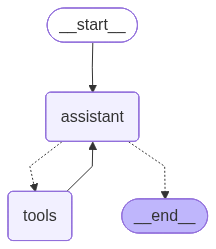

In [6]:
import os
from typing import Annotated, Literal
from typing_extensions import TypedDict
from dotenv import load_dotenv
from langchain_google_vertexai import ChatVertexAI
from langchain_core.messages import BaseMessage, HumanMessage
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode

load_dotenv()

# --- 1. Define Multiple Tools ---

def check_room_availability(room_type: str) -> str:
    """Checks if a specific room type (Deluxe, Suite, or Standard) is available."""
    rooms = {"deluxe": "Available", "suite": "Sold Out", "standard": "2 rooms left"}
    status = rooms.get(room_type.lower(), "Room type not found.")
    return f"Status for {room_type}: {status}"

def calculate_stay_cost(nights: int, price_per_night: int) -> str:
    """Calculates the total cost for a stay."""
    total = nights * price_per_night
    return f"The total cost for {nights} nights at ${price_per_night}/night is ${total}."

# --- 2. Setup LLM and Bind BOTH tools ---


llm = ChatVertexAI(
    model="gemini-2.5-pro",        # Vertex AI model name format
    project=os.getenv("GCP_PROJECT_ID"),   # Your GCP project ID
    location="us-central1",              # Region where Vertex AI is enabled
    temperature=0
)
# We pass a LIST of tools here
tools = [check_room_availability, calculate_stay_cost]
llm_with_tools = llm.bind_tools(tools)

# --- 3. Graph Structure ---

class AgentState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]

def call_assistant(state: AgentState):
    response = llm_with_tools.invoke(state["messages"])
    return {"messages": [response]}

def router(state: AgentState) -> Literal["tools", "__end__"]:
    last_msg = state["messages"][-1]
    if last_msg.tool_calls:
        return "tools"
    return "__end__" #to break the loop and end the graph execution if no tools are called

# --- 4. Build the Graph ---

builder = StateGraph(AgentState)

builder.add_node("assistant", call_assistant)
# The ToolNode automatically handles whichever tool the LLM picks!
builder.add_node("tools", ToolNode(tools))

builder.add_edge(START, "assistant")
builder.add_conditional_edges("assistant", router)
builder.add_edge("tools", "assistant")
# Note: We don't add an edge from "assistant" to END because the router will direct to END if no tools are called.


graph = builder.compile()
## Display the graph
from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

### Single Tool Test

In [7]:
print("--- Testing Scenario A: Availability ---")
# Initial input: A single question about rooms
input_a = {"messages": [HumanMessage(content="Is a Deluxe room available?")]}

# Invoke the graph
response_a = graph.invoke(input_a)

print(f"User: {input_a['messages'][0].content}")
print(f"Assistant: {response_a['messages'][-1].content}")

--- Testing Scenario A: Availability ---
User: Is a Deluxe room available?
Assistant: Yes, a Deluxe room is available. 



### Complex Multi-Step Test (The "ReAct" Power)

In [8]:
print("\n--- Testing Scenario B: Complex Request ---")
input_b = {"messages": [HumanMessage(content="Check if a deluxe is available. If so, what is the cost for 2 nights for $300 room?")]}

response_b = graph.invoke(input_b)

# This will print the final answer where the LLM explains the Suite status
print(f"Assistant: {response_b['messages'][-1].content}")


--- Testing Scenario B: Complex Request ---
Assistant: Yes, a Deluxe room is available. The total cost for 2 nights at $300/night is $600.


In [9]:
print("\n--- Testing Scenario C: Complex Request ---")
input_c = {"messages": [HumanMessage(content="Check if a Suite is available. If so, what is the cost for 2 nights at $300?")]}

# We use a new thread_id for a fresh conversation
config_c = {"configurable": {"thread_id": "session_3"}}
response_c = graph.invoke(input_c, config_c)

# This will print the final answer where the LLM explains the Suite status
print(f"Assistant: {response_c['messages'][-1].content}")


--- Testing Scenario C: Complex Request ---
Assistant: The Suite is sold out. The cost for a 2-night stay at $300 per night would be $600.
